# 2025/03/13 - What's wrong with Marco


## Summary

In this notebook we are going to try to understand what's going wrong with my attempt to replicate Marco's work. 

In [3]:
import pandas as pd

In [1]:
def read_hits_tab(file, library):
    """
    Arguments
    ---
    - file: File from where to read the input
    - library: Provides a name to the library
    """
    hits = pd.read_csv(
        file, 
        sep="\s+", comment='#', header=None
    )
    hits.columns=[
        'query_id', 'ref_id', 'identity', '_', '_', '_', 'qstart', 'qend', 'rstart', 'rend', 
        '_', '_', 'score', 'qstrand', 'rstrand', 'qrlength', 'BTOP', 'difaln', 'foo', '_',
        '_', 'unaligned', 'mate', '_', '_'
    ]
    hits = hits[['query_id', 'ref_id', 'identity', 'mate', 'foo', 'qstart', 'qend', 'rstart', 'rend', 'score', 'qstrand', 'rstrand', 'qrlength', 'difaln']]
    hits['library'] = library
    return hits

In [4]:
hits = read_hits_tab("../results/2025-03-12-b2s-test/blast-hits.PV64_21351_GCCAAT.tab", "PV64")
species = pd.read_json('../results/2025-03-12-presanchisdb/pabl20.reference.json')
hits = pd.merge(hits, species, left_on='ref_id', right_on='sequence_id', how='left')

In [5]:
hits

,query_id,ref_id,identity,mate,foo,qstart,qend,rstart,rend,score,qstrand,rstrand,qrlength,difaln,library,accession,sequence_id,taxid,organism,length
0,J00148:56:HM5WHBBXX:1:1101:17787:1508,JBEBTN010000088.1,100.0,-,-,1,32,51,20,32,plus,minus,32,3,PV64,GCA_040393785.1,JBEBTN010000088.1,273678,Microbacterium hydrocarbonoxydans,4029950
1,J00148:56:HM5WHBBXX:1:1101:17787:1508,AWQP01000014.1,100.0,-,-,1,32,80083,80114,32,plus,plus,32,3,PV64,GCA_000972175.1,AWQP01000014.1,1397690,Pseudomonas syringae pv. coryli str. NCPPB 4273,6096328
2,J00148:56:HM5WHBBXX:1:1101:17787:1508,AWQP01000067.1,100.0,-,-,1,32,63,32,32,plus,minus,32,3,PV64,GCA_000972175.1,AWQP01000067.1,1397690,Pseudomonas syringae pv. coryli str. NCPPB 4273,6096328
3,J00148:56:HM5WHBBXX:1:1101:28696:1701,JBEBTN010000088.1,100.0,-,-,1,32,51,20,32,plus,minus,32,3,PV64,GCA_040393785.1,JBEBTN010000088.1,273678,Microbacterium hydrocarbonoxydans,4029950
4,J00148:56:HM5WHBBXX:1:1101:28696:1701,AWQP01000014.1,100.0,-,-,1,32,80083,80114,32,plus,plus,32,3,PV64,GCA_000972175.1,AWQP01000014.1,1397690,Pseudomonas syringae pv. coryli str. NCPPB 4273,6096328
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112368,J00148:56:HM5WHBBXX:2:2228:20872:48139,AWQP01000067.1,100.0,-,-,1,32,63,32,32,plus,minus,32,3,PV64,GCA_000972175.1,AWQP01000067.1,1397690,Pseudomonas syringae pv. coryli str. NCPPB 4273,6096328
112369,J00148:56:HM5WHBBXX:2:2228:17472:48614,LMQW01000047.1,100.0,-,-,1,151,884,734,151,plus,minus,151,1,PV64,GCA_001425485.1,LMQW01000047.1,1736375,Aureimonas sp. Leaf427,5438231
112370,J00148:56:HM5WHBBXX:2:2228:25347:48825,JBEBTN010000088.1,100.0,-,-,1,32,51,20,32,plus,minus,32,3,PV64,GCA_040393785.1,JBEBTN010000088.1,273678,Microbacterium hydrocarbonoxydans,4029950
112371,J00148:56:HM5WHBBXX:2:2228:25347:48825,AWQP01000014.1,100.0,-,-,1,32,80083,80114,32,plus,plus,32,3,PV64,GCA_000972175.1,AWQP01000014.1,1397690,Pseudomonas syringae pv. coryli str. NCPPB 4273,6096328


In [6]:
hits.query('taxid==1267562')

,query_id,ref_id,identity,mate,foo,qstart,qend,rstart,rend,score,qstrand,rstrand,qrlength,difaln,library,accession,sequence_id,taxid,organism,length
10919,J00148:56:HM5WHBBXX:1:1201:3407:13623,CP010516.1,100.0,-,-,27,137,1466613,1466503,111,plus,minus,151,24,PV64,GCA_001281465.1,CP010516.1,1267562,Cupriavidus gilardii CR3,5578743
10920,J00148:56:HM5WHBBXX:1:1201:3407:13623,CP010516.1,100.0,-,-,27,137,3151448,3151558,111,plus,plus,151,24,PV64,GCA_001281465.1,CP010516.1,1267562,Cupriavidus gilardii CR3,5578743
10921,J00148:56:HM5WHBBXX:1:1201:3407:13623,CP010517.1,100.0,-,-,27,137,1905620,1905730,111,plus,plus,151,24,PV64,GCA_001281465.1,CP010517.1,1267562,Cupriavidus gilardii CR3,5578743
13368,J00148:56:HM5WHBBXX:1:1122:23612:46170,CP010516.1,100.0,-,-,8,27,969725,969744,20,plus,plus,29,4,PV64,GCA_001281465.1,CP010516.1,1267562,Cupriavidus gilardii CR3,5578743
33581,J00148:56:HM5WHBBXX:1:2114:26748:33492,CP010516.1,100.0,-,-,56,151,1466613,1466518,96,plus,minus,151,25,PV64,GCA_001281465.1,CP010516.1,1267562,Cupriavidus gilardii CR3,5578743
33582,J00148:56:HM5WHBBXX:1:2114:26748:33492,CP010516.1,100.0,-,-,56,151,2958602,2958697,96,plus,plus,151,25,PV64,GCA_001281465.1,CP010516.1,1267562,Cupriavidus gilardii CR3,5578743
33583,J00148:56:HM5WHBBXX:1:2114:26748:33492,CP010516.1,100.0,-,-,56,151,3151448,3151543,96,plus,plus,151,25,PV64,GCA_001281465.1,CP010516.1,1267562,Cupriavidus gilardii CR3,5578743
33584,J00148:56:HM5WHBBXX:1:2114:26748:33492,CP010517.1,100.0,-,-,56,151,1905620,1905715,96,plus,plus,151,25,PV64,GCA_001281465.1,CP010517.1,1267562,Cupriavidus gilardii CR3,5578743
41353,J00148:56:HM5WHBBXX:1:2125:16620:32297,CP010516.1,100.0,-,-,55,151,1466613,1466517,97,plus,minus,151,25,PV64,GCA_001281465.1,CP010516.1,1267562,Cupriavidus gilardii CR3,5578743
41354,J00148:56:HM5WHBBXX:1:2125:16620:32297,CP010516.1,100.0,-,-,55,151,2958602,2958698,97,plus,plus,151,25,PV64,GCA_001281465.1,CP010516.1,1267562,Cupriavidus gilardii CR3,5578743


In [7]:
hits = hits.query(f'identity == 100')
hits['aln_len'] = hits['qend'] - hits['qstart']
hits = hits.query(f'aln_len > 125')
# hits = hits.query(f'difaln < 2')
hits

/tmp/ipykernel_2664848/1707990335.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hits['aln_len'] = hits['qend'] - hits['qstart']


,query_id,ref_id,identity,mate,foo,qstart,qend,rstart,rend,score,...,rstrand,qrlength,difaln,library,accession,sequence_id,taxid,organism,length,aln_len
25,J00148:56:HM5WHBBXX:1:1101:9232:4127,AKVP01000085.1,100.0,-,-,1,151,764,914,151,...,plus,151,1,PV64,GCA_000299315.2,AKVP01000085.1,1197720,Microbacterium barkeri 2011-R4,3627873,150
32,J00148:56:HM5WHBBXX:1:1101:19136:5323,AKVP01000085.1,100.0,-,-,1,140,1558,1697,140,...,plus,151,1,PV64,GCA_000299315.2,AKVP01000085.1,1197720,Microbacterium barkeri 2011-R4,3627873,139
39,J00148:56:HM5WHBBXX:1:1101:7659:5622,LMQW01000042.1,100.0,-,-,3,138,790,655,136,...,minus,151,2,PV64,GCA_001425485.1,LMQW01000042.1,1736375,Aureimonas sp. Leaf427,5438231,135
40,J00148:56:HM5WHBBXX:1:1101:7659:5622,LMQW01000042.1,100.0,-,-,1,136,655,790,136,...,plus,151,2,PV64,GCA_001425485.1,LMQW01000042.1,1736375,Aureimonas sp. Leaf427,5438231,135
41,J00148:56:HM5WHBBXX:1:1101:7659:5622,JABUOH010000044.1,100.0,-,-,3,138,528,393,136,...,minus,151,2,PV64,GCA_013391955.1,JABUOH010000044.1,479893,Candidatus Phytoplasma pruni,790517,135
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112308,J00148:56:HM5WHBBXX:2:2228:30817:43708,AKVP01000087.1,100.0,-,-,1,128,1191,1318,128,...,plus,151,1,PV64,GCA_000299315.2,AKVP01000087.1,1197720,Microbacterium barkeri 2011-R4,3627873,127
112315,J00148:56:HM5WHBBXX:2:2228:8988:44711,AKVP01000087.1,100.0,-,-,5,151,1340,1194,147,...,minus,151,1,PV64,GCA_000299315.2,AKVP01000087.1,1197720,Microbacterium barkeri 2011-R4,3627873,146
112316,J00148:56:HM5WHBBXX:2:2228:8988:44711,AKVP01000087.1,100.0,-,-,1,148,1193,1340,148,...,plus,151,1,PV64,GCA_000299315.2,AKVP01000087.1,1197720,Microbacterium barkeri 2011-R4,3627873,147
112345,J00148:56:HM5WHBBXX:2:2228:3112:46170,AKVP01000087.1,100.0,-,-,1,146,958,813,146,...,minus,151,1,PV64,GCA_000299315.2,AKVP01000087.1,1197720,Microbacterium barkeri 2011-R4,3627873,145


In [8]:
hits_strands = hits.groupby(['query_id', 'ref_id'])['rstrand'].apply(list).reset_index()
hits_strands['is_paired'] = hits_strands['rstrand'].apply(len)
hits_strands

,query_id,ref_id,rstrand,is_paired
0,J00148:56:HM5WHBBXX:1:1101:10125:45836,AKVP01000087.1,"[minus, plus]",2
1,J00148:56:HM5WHBBXX:1:1101:11028:6607,LMQW01000042.1,"[plus, minus]",2
2,J00148:56:HM5WHBBXX:1:1101:13007:25369,LMQW01000047.1,"[minus, plus]",2
3,J00148:56:HM5WHBBXX:1:1101:14143:15768,LMNW01000030.1,"[plus, minus]",2
4,J00148:56:HM5WHBBXX:1:1101:14397:16840,LMNW01000030.1,[minus],1
...,...,...,...,...
12999,J00148:56:HM5WHBBXX:2:2228:6431:32015,LMRN01000005.1,"[minus, plus]",2
13000,J00148:56:HM5WHBBXX:2:2228:7141:33879,AKVP01000087.1,[minus],1
13001,J00148:56:HM5WHBBXX:2:2228:7141:33879,LMNW01000030.1,[plus],1
13002,J00148:56:HM5WHBBXX:2:2228:8988:44711,AKVP01000087.1,"[minus, plus]",2


<Axes: >

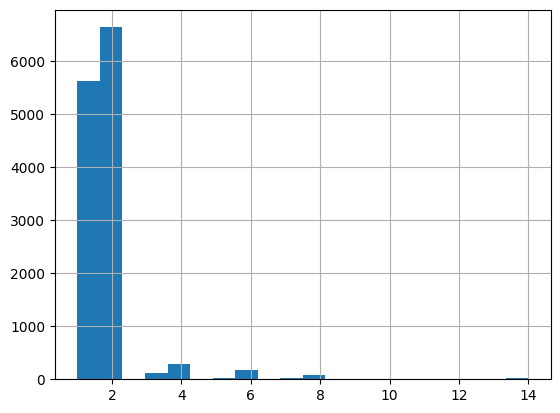

In [9]:
hits_strands['is_paired'].hist(bins=20)

In [10]:
hits_strands.query('is_paired == 2')

,query_id,ref_id,rstrand,is_paired
0,J00148:56:HM5WHBBXX:1:1101:10125:45836,AKVP01000087.1,"[minus, plus]",2
1,J00148:56:HM5WHBBXX:1:1101:11028:6607,LMQW01000042.1,"[plus, minus]",2
2,J00148:56:HM5WHBBXX:1:1101:13007:25369,LMQW01000047.1,"[minus, plus]",2
3,J00148:56:HM5WHBBXX:1:1101:14143:15768,LMNW01000030.1,"[plus, minus]",2
5,J00148:56:HM5WHBBXX:1:1101:17452:9614,LMQW01000047.1,"[minus, plus]",2
...,...,...,...,...
12997,J00148:56:HM5WHBBXX:2:2228:6431:32015,LMPQ01000005.1,"[plus, minus]",2
12998,J00148:56:HM5WHBBXX:2:2228:6431:32015,LMPX01000001.1,"[plus, minus]",2
12999,J00148:56:HM5WHBBXX:2:2228:6431:32015,LMRN01000005.1,"[minus, plus]",2
13002,J00148:56:HM5WHBBXX:2:2228:8988:44711,AKVP01000087.1,"[minus, plus]",2


In [11]:
foo = pd.merge(hits_strands.query('is_paired==2'), pd.read_json('../results/2025-03-12-presanchisdb/pabl20.reference.json'), right_on='sequence_id', left_on='ref_id', how='left')
foo

,query_id,ref_id,rstrand,is_paired,accession,sequence_id,taxid,organism,length
0,J00148:56:HM5WHBBXX:1:1101:10125:45836,AKVP01000087.1,"[minus, plus]",2,GCA_000299315.2,AKVP01000087.1,1197720,Microbacterium barkeri 2011-R4,3627873
1,J00148:56:HM5WHBBXX:1:1101:11028:6607,LMQW01000042.1,"[plus, minus]",2,GCA_001425485.1,LMQW01000042.1,1736375,Aureimonas sp. Leaf427,5438231
2,J00148:56:HM5WHBBXX:1:1101:13007:25369,LMQW01000047.1,"[minus, plus]",2,GCA_001425485.1,LMQW01000047.1,1736375,Aureimonas sp. Leaf427,5438231
3,J00148:56:HM5WHBBXX:1:1101:14143:15768,LMNW01000030.1,"[plus, minus]",2,GCA_001423125.1,LMNW01000030.1,1736266,Duganella sp. Leaf126,5315014
4,J00148:56:HM5WHBBXX:1:1101:17452:9614,LMQW01000047.1,"[minus, plus]",2,GCA_001425485.1,LMQW01000047.1,1736375,Aureimonas sp. Leaf427,5438231
...,...,...,...,...,...,...,...,...,...
6632,J00148:56:HM5WHBBXX:2:2228:6431:32015,LMPQ01000005.1,"[plus, minus]",2,GCA_001423905.1,LMPQ01000005.1,1736293,Frigoribacterium sp. Leaf186,3439013
6633,J00148:56:HM5WHBBXX:2:2228:6431:32015,LMPX01000001.1,"[plus, minus]",2,GCA_001424005.1,LMPX01000001.1,1736299,Sphingomonas sp. Leaf198,4201813
6634,J00148:56:HM5WHBBXX:2:2228:6431:32015,LMRN01000005.1,"[minus, plus]",2,GCA_001426145.1,LMRN01000005.1,1736300,Rhodococcus sp. Leaf225,4713325
6635,J00148:56:HM5WHBBXX:2:2228:8988:44711,AKVP01000087.1,"[minus, plus]",2,GCA_000299315.2,AKVP01000087.1,1197720,Microbacterium barkeri 2011-R4,3627873


In [12]:
foo[['organism', 'taxid']].value_counts().reset_index()

,organism,taxid,count
0,Microbacterium barkeri 2011-R4,1197720,1396
1,Aureimonas sp. Leaf427,1736375,895
2,Duganella sp. Leaf126,1736266,321
3,Sphingomonas sp. Leaf208,1735679,258
4,Sphingomonas sp. Leaf198,1736299,232
...,...,...,...
165,Pantoea alhagi,1891675,1
166,Pandoraea thiooxydans,445709,1
167,Micromonospora saelicesensis,285676,1
168,Microbacterium sp. SA39,1263625,1


In [13]:
pd.read_json('../results/2025-03-12-presanchisdb/pabl20.reference.json').query('taxid == 1267562')

,accession,sequence_id,taxid,organism,length
7248,GCA_001281465.1,CP010516.1,1267562,Cupriavidus gilardii CR3,5578743
7249,GCA_001281465.1,CP010517.1,1267562,Cupriavidus gilardii CR3,5578743


In [14]:
hits = read_hits_tab("../results/2025-03-12-b2s-test/paired.tab", "PV64")
species = pd.read_json('../results/2025-03-12-presanchisdb/pabl20.reference.json')
hits = pd.merge(hits, species, left_on='ref_id', right_on='sequence_id', how='left')
hits

,query_id,ref_id,identity,mate,foo,qstart,qend,rstart,rend,score,qstrand,rstrand,qrlength,difaln,library,accession,sequence_id,taxid,organism,length
0,J00148:56:HM5WHBBXX:1:1116:24241:33826,CP010517.1,100,-,-,10,29,659482,659501,20,plus,plus,30,1,PV64,GCA_001281465.1,CP010517.1,1267562,Cupriavidus gilardii CR3,5578743
1,J00148:56:HM5WHBBXX:1:1122:23612:46170,CP010516.1,100,-,-,8,27,969725,969744,20,plus,plus,29,1,PV64,GCA_001281465.1,CP010516.1,1267562,Cupriavidus gilardii CR3,5578743
2,J00148:56:HM5WHBBXX:1:1126:20486:17825,CP010516.1,100,-,-,36,147,1466614,1466503,112,plus,minus,151,3,PV64,GCA_001281465.1,CP010516.1,1267562,Cupriavidus gilardii CR3,5578743
3,J00148:56:HM5WHBBXX:1:1126:20486:17825,CP010516.1,100,-,-,7,118,1466503,1466614,112,plus,plus,151,3,PV64,GCA_001281465.1,CP010516.1,1267562,Cupriavidus gilardii CR3,5578743
4,J00148:56:HM5WHBBXX:1:1126:20486:17825,CP010516.1,100,-,-,36,147,3151447,3151558,112,plus,plus,151,3,PV64,GCA_001281465.1,CP010516.1,1267562,Cupriavidus gilardii CR3,5578743
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69,J00148:56:HM5WHBBXX:2:2123:16396:45379,CP010516.1,100,-,-,1,101,3152360,3152460,101,plus,plus,135,2,PV64,GCA_001281465.1,CP010516.1,1267562,Cupriavidus gilardii CR3,5578743
70,J00148:56:HM5WHBBXX:2:2123:16396:45379,CP010516.1,100,-,-,1,101,2959611,2959511,101,plus,minus,148,2,PV64,GCA_001281465.1,CP010516.1,1267562,Cupriavidus gilardii CR3,5578743
71,J00148:56:HM5WHBBXX:2:2201:14519:24437,CP010516.1,100,-,-,34,144,1466613,1466503,111,plus,minus,151,3,PV64,GCA_001281465.1,CP010516.1,1267562,Cupriavidus gilardii CR3,5578743
72,J00148:56:HM5WHBBXX:2:2201:14519:24437,CP010516.1,100,-,-,34,144,3151448,3151558,111,plus,plus,151,3,PV64,GCA_001281465.1,CP010516.1,1267562,Cupriavidus gilardii CR3,5578743


In [15]:
hits = hits.query(f'identity == 100')
hits['aln_len'] = hits['qend'] - hits['qstart']
# hits = hits.query(f'aln_len > 125')
# hits = hits.query(f'difaln < 2')
hits

,query_id,ref_id,identity,mate,foo,qstart,qend,rstart,rend,score,...,rstrand,qrlength,difaln,library,accession,sequence_id,taxid,organism,length,aln_len
0,J00148:56:HM5WHBBXX:1:1116:24241:33826,CP010517.1,100,-,-,10,29,659482,659501,20,...,plus,30,1,PV64,GCA_001281465.1,CP010517.1,1267562,Cupriavidus gilardii CR3,5578743,19
1,J00148:56:HM5WHBBXX:1:1122:23612:46170,CP010516.1,100,-,-,8,27,969725,969744,20,...,plus,29,1,PV64,GCA_001281465.1,CP010516.1,1267562,Cupriavidus gilardii CR3,5578743,19
2,J00148:56:HM5WHBBXX:1:1126:20486:17825,CP010516.1,100,-,-,36,147,1466614,1466503,112,...,minus,151,3,PV64,GCA_001281465.1,CP010516.1,1267562,Cupriavidus gilardii CR3,5578743,111
3,J00148:56:HM5WHBBXX:1:1126:20486:17825,CP010516.1,100,-,-,7,118,1466503,1466614,112,...,plus,151,3,PV64,GCA_001281465.1,CP010516.1,1267562,Cupriavidus gilardii CR3,5578743,111
4,J00148:56:HM5WHBBXX:1:1126:20486:17825,CP010516.1,100,-,-,36,147,3151447,3151558,112,...,plus,151,3,PV64,GCA_001281465.1,CP010516.1,1267562,Cupriavidus gilardii CR3,5578743,111
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69,J00148:56:HM5WHBBXX:2:2123:16396:45379,CP010516.1,100,-,-,1,101,3152360,3152460,101,...,plus,135,2,PV64,GCA_001281465.1,CP010516.1,1267562,Cupriavidus gilardii CR3,5578743,100
70,J00148:56:HM5WHBBXX:2:2123:16396:45379,CP010516.1,100,-,-,1,101,2959611,2959511,101,...,minus,148,2,PV64,GCA_001281465.1,CP010516.1,1267562,Cupriavidus gilardii CR3,5578743,100
71,J00148:56:HM5WHBBXX:2:2201:14519:24437,CP010516.1,100,-,-,34,144,1466613,1466503,111,...,minus,151,3,PV64,GCA_001281465.1,CP010516.1,1267562,Cupriavidus gilardii CR3,5578743,110
72,J00148:56:HM5WHBBXX:2:2201:14519:24437,CP010516.1,100,-,-,34,144,3151448,3151558,111,...,plus,151,3,PV64,GCA_001281465.1,CP010516.1,1267562,Cupriavidus gilardii CR3,5578743,110


In [19]:
pd.read_csv("../results/2025-03-12-b2s-test/blastn.read1.tab", sep='\t', header=None, names=['seq_id', 'ref_id', 'identity', 'length', 'mismatch', 'gapopen', 'qstart', 'qend', 'sstart', 'send', 'evalue', 'bitscore']).query('length > 125')

,seq_id,ref_id,identity,length,mismatch,gapopen,qstart,qend,sstart,send,evalue,bitscore
